# NB0: Data Quality, Integrity, and Ground Truth Audit
- **Question:** Is the underlying ground truth data valid, reliable, and free from systematic bias?
- **Primary GT:** Platinum Consensus
- **KL1 Strategy:** Exclude (Strategy A) as primary, but testing all three for data loading.
- **Hypothesis:** The original public repository labels contain systematic, directionally biased noise that misclassifies true pathology as healthy.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy import stats
from sklearn.metrics import cohen_kappa_score
import statsmodels.api as sm
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
import warnings
import sys, os; sys.path.append(os.path.abspath(".")); sys.path.append(os.path.abspath("..")); import helpers

warnings.filterwarnings("ignore")

# Define bootstrap function for CI
def bootstrap_ci(data, func, n_iterations=1000, alpha=0.05, seed=42):
    np.random.seed(seed)
    stats_dist = []
    n = len(data)
    for _ in range(n_iterations):
        indices = np.random.randint(0, n, n)
        sample = data.iloc[indices] if isinstance(data, pd.DataFrame) else data[indices]
        stats_dist.append(func(sample))
    return np.percentile(stats_dist, [alpha/2 * 100, (1 - alpha/2) * 100])


## Section 1: Pipeline Validation

In [2]:
print("--- Pipeline Validation ---")
strategies = ['exclude', 'clinical', 'sensitivity_1']
data_dict = {}

for s in strategies:
    df_s = helpers.load_data(s)
    data_dict[s] = df_s
    print(f"Strategy: {s} | Shape: {df_s.shape} | Images: {df_s['trial_image_name'].nunique()}")

# Use exclude as default
df = data_dict['exclude']
df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

print("\n--- Integrity Checks (Exclude Strategy) ---")
print(f"Participants: {df['participant_id'].nunique()}")
print(f"Trials: {len(df)}")
print(f"Images: {df['trial_image_name'].nunique()}")
print("\nSession distribution:")
print(df['session'].value_counts())
print("\nTreatment group balance:")
print(df.groupby('treatment_group')['participant_id'].nunique())

# Discrepancy Check
if 'ground_truth_binary' in df.columns:
    mismatches = df[df['ground_truth_binary'] != df['gt_original_binary']]
    if len(mismatches) > 0:
        print(f"\nWARNING: Found {len(mismatches)} trial rows where participants.csv 'ground_truth_binary' differs from 'gt_original_binary' derived from the radiologist file!")
    else:
        print("\nAll original binary labels match between data sources.")


--- Pipeline Validation ---
Data Loading: 51 participants selected (from 68 initial).
Strategy: exclude | Shape: (2754, 84) | Images: 27
Data Loading: 51 participants selected (from 68 initial).
Strategy: clinical | Shape: (5100, 84) | Images: 50
Data Loading: 51 participants selected (from 68 initial).
Strategy: sensitivity_1 | Shape: (5100, 84) | Images: 50

--- Integrity Checks (Exclude Strategy) ---
Participants: 51
Trials: 2754
Images: 27

Session distribution:
session
2    1377
1    1377
Name: count, dtype: int64

Treatment group balance:
treatment_group
0    27
1    24
Name: participant_id, dtype: int64

All original binary labels match between data sources.


## Section 2: Radiologist Inter-rater Reliability

In [3]:
print("--- Radiologist Inter-rater Reliability ---")
rad_df = pd.read_csv('data/Radiologist_Ground_Truth.csv')
rad_annotations = rad_df[['Rad1', 'rad2', 'rad3']]

def get_fleiss(data_matrix):
    agg, _ = aggregate_raters(data_matrix.values)
    return fleiss_kappa(agg)

fk_5 = get_fleiss(rad_annotations)
print(f"Fleiss Kappa (0-4 KL grades): {fk_5:.3f}")

# Bootstrap CI for Fleiss 5-class
ci_5 = bootstrap_ci(rad_annotations, get_fleiss)
print(f"95% CI: [{ci_5[0]:.3f}, {ci_5[1]:.3f}]")

# Binary Fleiss Kappa
rad_bin = rad_df[rad_df['gt_plat_kl'] != 1].copy()
rad_bin_vals = np.zeros((len(rad_bin), 3))
rad_bin_vals[:, 0] = (rad_bin['Rad1'] >= 2).astype(int)
rad_bin_vals[:, 1] = (rad_bin['rad2'] >= 2).astype(int)
rad_bin_vals[:, 2] = (rad_bin['rad3'] >= 2).astype(int)
rad_bin_vals_df = pd.DataFrame(rad_bin_vals)

fk_2 = get_fleiss(rad_bin_vals_df)
print(f"\nFleiss Kappa (Binary, excluding KL1): {fk_2:.3f}")
ci_2 = bootstrap_ci(rad_bin_vals_df, get_fleiss)
print(f"95% CI: [{ci_2[0]:.3f}, {ci_2[1]:.3f}]")

print("\n--- Pairwise Cohen's Kappa ---")
pairs = [('Rad1', 'rad2'), ('Rad1', 'rad3'), ('rad2', 'rad3')]
for r1, r2 in pairs:
    def get_cohen(df_sample):
        return cohen_kappa_score(df_sample[r1], df_sample[r2])
    k = get_cohen(rad_df)
    ci = bootstrap_ci(rad_df, get_cohen)
    print(f"{r1} vs {r2}: {k:.3f} (95% CI: [{ci[0]:.3f}, {ci[1]:.3f}])")

# Exact and Adjacent Agreement
def calc_agreement(df_sample):
    exact = 0
    adj = 0
    n = len(df_sample)
    for _, row in df_sample.iterrows():
        vals = [row['Rad1'], row['rad2'], row['rad3']]
        if vals[0] == vals[1] == vals[2]:
            exact += 1
        elif max(vals) - min(vals) <= 1:
            adj += 1
    return exact/n, (exact+adj)/n

exact_pct, adj_pct = calc_agreement(rad_df)
print(f"\nExact Agreement: {exact_pct*100:.1f}%")
print(f"Exact + Adjacent (within 1 grade) Agreement: {adj_pct*100:.1f}%")


--- Radiologist Inter-rater Reliability ---
Fleiss Kappa (0-4 KL grades): 0.181
95% CI: [0.042, 0.300]

Fleiss Kappa (Binary, excluding KL1): 0.517
95% CI: [0.175, 0.752]

--- Pairwise Cohen's Kappa ---
Rad1 vs rad2: 0.163 (95% CI: [-0.003, 0.340])
Rad1 vs rad3: 0.117 (95% CI: [-0.075, 0.301])
rad2 vs rad3: 0.298 (95% CI: [0.095, 0.486])

Exact Agreement: 16.0%
Exact + Adjacent (within 1 grade) Agreement: 84.0%


## Section 3: Ground Truth Transition Analysis

In [4]:
print("--- 5x5 Transition Matrix (All 50 Images) ---")
df_img_all = helpers.image_summary(data_dict['clinical'])
mat = pd.crosstab(df_img_all['gt_original'], df_img_all['gt_plat_kl'], margins=True)
print(mat)

print("\n--- 3-Way Transition Table (All 50 Images) ---")
# Simplified 3-way table
# Original class (0, 2+) vs platinum class (0, 1, 2+)
def orig_class(x): return 0 if x==0 else 2
def plat_class(x): 
    if x==0: return 0
    if x==1: return 1
    return 2

df_img_all['orig_3way'] = df_img_all['gt_original'].apply(orig_class)
df_img_all['plat_3way'] = df_img_all['gt_plat_kl'].apply(plat_class)

t3 = pd.crosstab(df_img_all['orig_3way'], df_img_all['plat_3way'])
print(t3)

# Binomial test for directional bias
fn_fp_counts = df_img_all['label_direction'].value_counts()
fn_cases = fn_fp_counts.get('fn_corrected', 0)
fp_cases = fn_fp_counts.get('fp_corrected', 0) 
ambig_neg_to_kl1 = fn_fp_counts.get('ambig_from_neg', 0)
ambig_pos_to_kl1 = fn_fp_counts.get('ambig_from_pos', 0)

misses = fn_cases + ambig_neg_to_kl1
total_changes = fn_cases + fp_cases
if total_changes > 0:
    res = stats.binomtest(fn_cases, n=total_changes, p=0.5, alternative='greater')
    print(f"\nBinomial test for directional bias (FN > FP): p={res.pvalue:.4f}")

# Sankey Diagram
source = []
target = []
value = []
for o in [0, 2, 3, 4]:
    for p in [0, 1, 2, 3, 4]:
        count = len(df_img_all[(df_img_all['gt_original']==o) & (df_img_all['gt_plat_kl']==p)])
        if count > 0:
            source.append(o)
            target.append(p + 5)
            value.append(count)

labels = ["Orig KL0", "Orig KL1", "Orig KL2", "Orig KL3", "Orig KL4",
          "Plat KL0", "Plat KL1", "Plat KL2", "Plat KL3", "Plat KL4"]

fig = go.Figure(data=[go.Sankey(
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = labels),
    link = dict(source = source, target = target, value = value)
)])
fig.update_layout(title_text="Ground Truth Transition (Including KL1)", font_size=10)
fig.show()


--- 5x5 Transition Matrix (All 50 Images) ---
gt_plat_kl   0   1   2  3  4  All
gt_original                      
0            6  14   5  0  0   25
2            0   9   5  1  0   15
3            0   0   3  5  1    9
4            0   0   0  1  0    1
All          6  23  13  7  1   50

--- 3-Way Transition Table (All 50 Images) ---
plat_3way  0   1   2
orig_3way           
0          6  14   5
2          0   9  16

Binomial test for directional bias (FN > FP): p=0.0312


## Section 4: AI Confidence on Mislabeled Images

--- AI Confidence on Mislabeled Images ---
Mean AI Confidence by Direction:
label_direction
fn_corrected    0.317100
stable_neg      0.710433
stable_pos      0.776156
Name: ai_confidence, dtype: float64


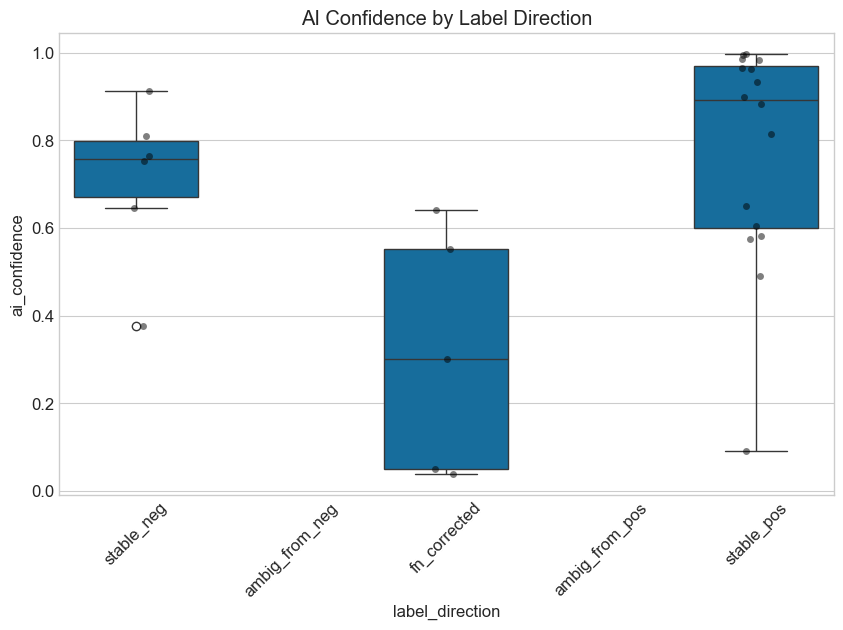

Kruskal-Wallis testing AI confidence across subgroups:
Statistic: 8.631, p-value: 0.0134


In [5]:
print("--- AI Confidence on Mislabeled Images ---")
print("Mean AI Confidence by Direction:")
print(df_img.groupby('label_direction')['ai_confidence'].mean())

plt.figure(figsize=(10,6))
sns.boxplot(data=df_img, x='label_direction', y='ai_confidence', order=['stable_neg', 'ambig_from_neg', 'fn_corrected', 'ambig_from_pos', 'stable_pos'])
sns.stripplot(data=df_img, x='label_direction', y='ai_confidence', color='black', alpha=0.5, order=['stable_neg', 'ambig_from_neg', 'fn_corrected', 'ambig_from_pos', 'stable_pos'])
plt.title("AI Confidence by Label Direction")
plt.xticks(rotation=45)
plt.show()

groups = [group['ai_confidence'].values for name, group in df_img.groupby('label_direction')]
kw = stats.kruskal(*groups)
print("Kruskal-Wallis testing AI confidence across subgroups:")
print(f"Statistic: {kw.statistic:.3f}, p-value: {kw.pvalue:.4f}")


## Section 5: Participant Data Quality

--- Participant Data Quality ---


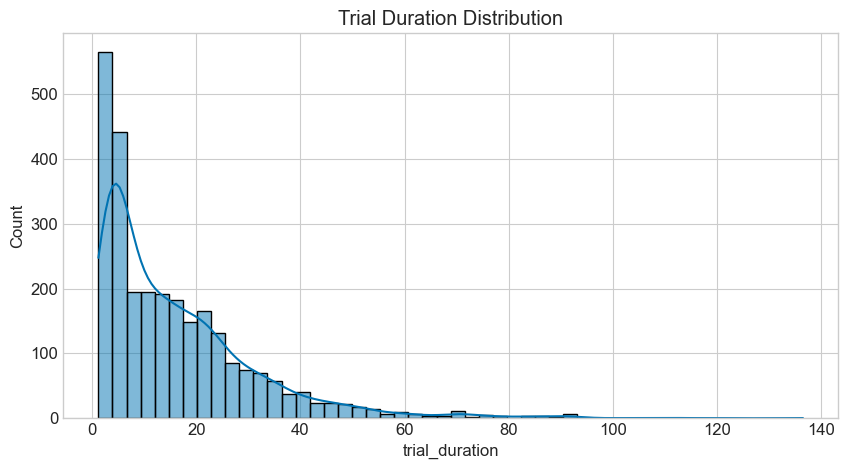

Speeders identified (mean duration < 8.2s): 0

Missing Data Audit:
phase1_video_watched    1296
reverted_decision       1377
symptom1                1377
symptom2                1377
dtype: int64
Data Loading: 51 participants selected (from 68 initial).

Data Quality Report Card:
| Metric                               |   Value |
|:-------------------------------------|--------:|
| Total Participants                   |      51 |
| Completed Both Sessions              |      51 |
| Flagged Speeders                     |       0 |
| Images with GT Shifts (Full Dataset) |      14 |


In [6]:
print("--- Participant Data Quality ---")
plt.figure(figsize=(10,5))
sns.histplot(df["trial_duration"], kde=True, bins=50)
plt.title("Trial Duration Distribution")
plt.show()

speeders = df.groupby("participant_id")["trial_duration"].mean()
speeder_threshold = speeders.mean() - 2*speeders.std()
flagged_speeders = speeders[speeders < speeder_threshold]
print(f"Speeders identified (mean duration < {speeder_threshold:.1f}s): {len(flagged_speeders)}")

# Missing Data Audit
print("")
print("Missing Data Audit:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Report Card
full_img_df = helpers.image_summary(helpers.load_data("clinical"))
report = pd.DataFrame({
    "Metric": ["Total Participants", "Completed Both Sessions", "Flagged Speeders", "Images with GT Shifts (Full Dataset)"],
    "Value": [df["participant_id"].nunique(), df[df["session"]==2]["participant_id"].nunique(), len(flagged_speeders), full_img_df["label_changed"].sum()]
})
print("")
print("Data Quality Report Card:")
print(report.to_markdown(index=False))
